# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

### Credit Card Dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas de comportamiento** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo *es* encontrar segmentos de clientes para definir una estrategia de marketing. Esto es aprendizaje no supervisado «de verdad»: no podemos calcular ARI porque no hay verdad de referencia; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

Además, al ser numérico y con escalas muy distintas, aparecen dos pasos que con las setas no hicieron falta: **imputar nulos** y **escalar**.

In [45]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score,davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
# Importad el resto a medida que los necesiteis (TSNE, GMM, DBSCAN, metricas...)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [25]:
# Leer el csv (esta en 'data/credit_card.csv') y mostrar las primeras filas.
df = pd.read_csv('data/credit_card.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Exploración de datos

In [26]:
# Tamano del dataset.
print(f"El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset contiene 8950 filas y 18 columnas.


In [27]:
# Descripcion estadistica. Fijaos en las escalas tan distintas entre variables.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [28]:
# Tipos de datos.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

#### Nulos

In [29]:
# Contar nulos por variable (mostrad solo las que tengan).
nulos = df.isnull().sum()
nulos[nulos > 0]

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [30]:
# 1. Eliminar CUST_ID (es un identificador)
df_clean = df.drop(columns=['CUST_ID'])
# 2. Imputar los nulos con la mediana de cada columna
df_clean = df_clean.fillna(df_clean.median())
# 3. Verificar que ya no hay nulos
print("Nulos restantes:", df_clean.isnull().sum().sum())

Nulos restantes: 0


#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

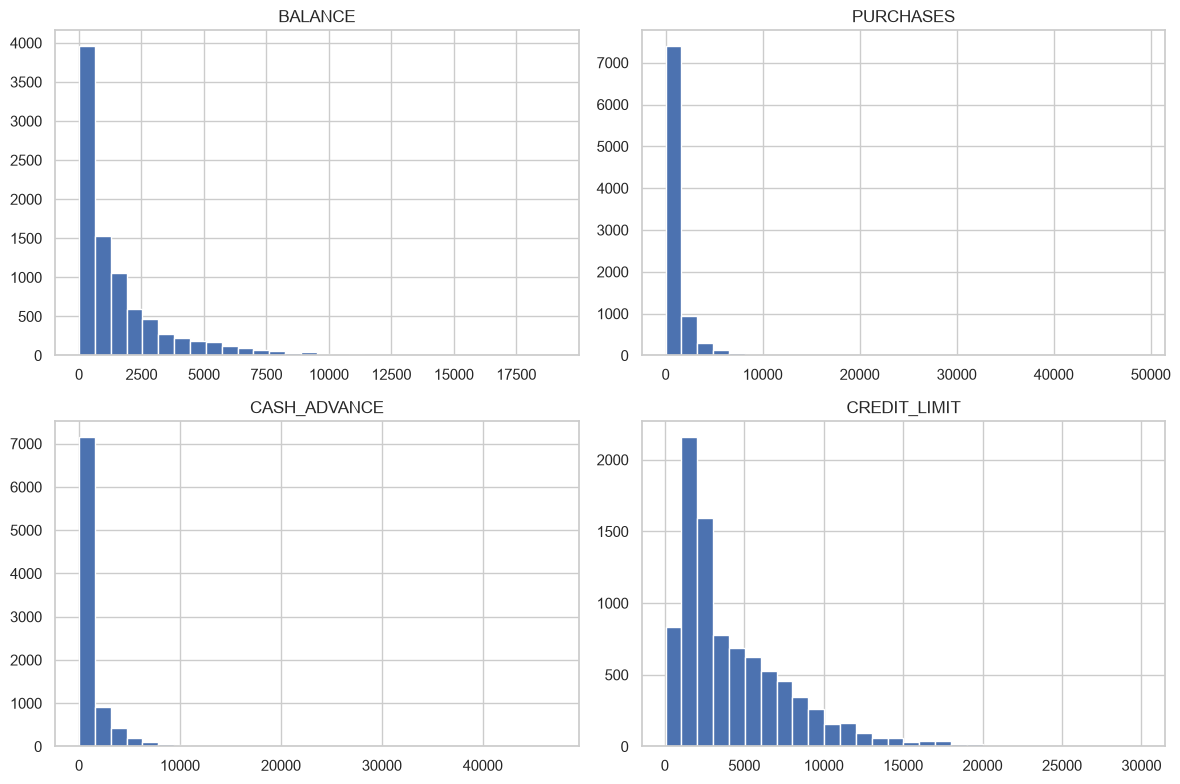

In [31]:
# Pintar histogramas de unas cuantas variables (df[cols].hist...) y observar el sesgo.
variables_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']
df_clean[variables_to_plot].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [32]:
# Aplicar StandardScaler a df -> X (array escalado)
scaler = StandardScaler()
X = scaler.fit_transform(df_clean)

## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

In [33]:
# 1. Ajustar PCA sin fijar n_components y mirar explained_variance_ratio_
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",42
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to

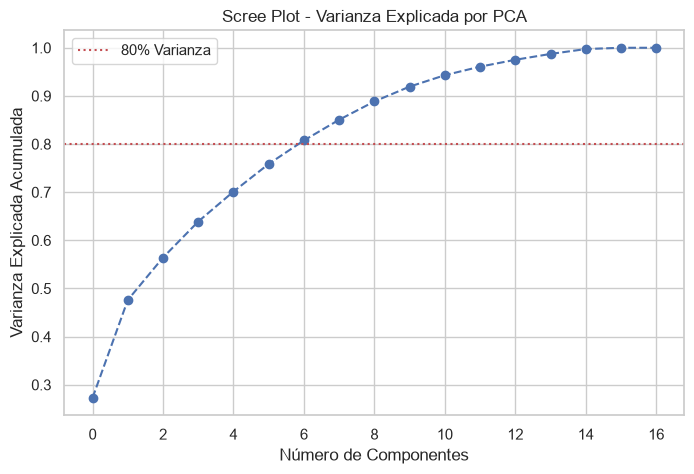

In [34]:
# 2. Pintar la varianza explicada acumulada (scree plot)
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Scree Plot - Varianza Explicada por PCA')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Varianza')
plt.legend()
plt.show()

In [35]:
# 3. Decidir cuantas componentes hacen falta para ~80% de varianza
variance_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = np.argmax(variance_acum >= 0.80) + 1
print(f"Se necesitan {n_components_80} componentes para explicar al menos el 80% de la varianza.")

Se necesitan 7 componentes para explicar al menos el 80% de la varianza.


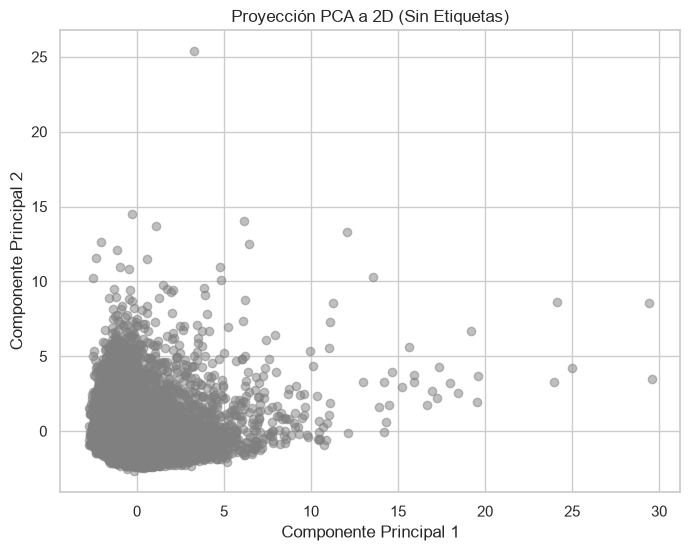

In [36]:
# Proyectar X a 2 componentes y pintar el scatter (aun sin colores: no hay etiqueta)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color='gray')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección PCA a 2D (Sin Etiquetas)')
plt.show()

A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

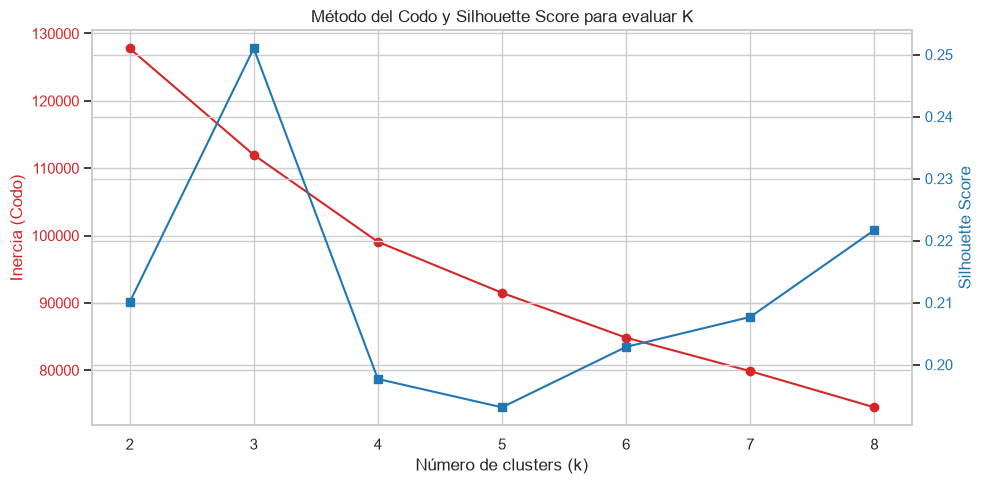

El mejor número de clusters según Silhouette es k = 3


In [37]:
k_values = range(2, 9)
inercias, silhouettes = [], []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, kmeans.labels_))
# Pintar las dos curvas y elegir best_k (el de mayor silhouette)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (Codo)', color=color)
ax1.plot(k_values, inercias, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_values, silhouettes, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del Codo y Silhouette Score para evaluar K')
fig.tight_layout()
plt.show()

best_k = k_values[np.argmax(silhouettes)]
print(f"El mejor número de clusters según Silhouette es k = {best_k}")

### K-Means final

In [38]:
# Entrenar KMeans con best_k, guardar las etiquetas y mirar el tamano de cada cluster
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans_final.fit_transform(X) # u usar .fit_predict(X)
df_clean['cluster_kmeans'] = kmeans_final.labels_

print("Tamaño de cada cluster:")
print(df_clean['cluster_kmeans'].value_counts())

Tamaño de cada cluster:
cluster_kmeans
1    6114
2    1561
0    1275
Name: count, dtype: int64


### Comparativa de algoritmos

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y *Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).

In [39]:
# Definir evaluar(nombre, labels, X) con silhouette, davies_bouldin y calinski_harabasz
def evaluar(nombre, labels, X_data):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    print(f"--- {nombre} ---")
    print(f"Silhouette: {sil:.4f} (más alto mejor)")
    print(f"Davies-Bouldin: {db:.4f} (más bajo mejor)")
    print(f"Calinski-Harabasz: {ch:.4f} (más alto mejor)\n")

# Evaluar KMeans
evaluar("K-Means", kmeans_final.labels_, X)

# (sin ARI: no hay etiqueta). Comparar KMeans, Aglomerativo y GMM.
# Evaluar Aglomerativo (tomando una muestra o sobre todo X si no tarda demasiado)
agg = AgglomerativeClustering(n_clusters=best_k)
labels_agg = agg.fit_predict(X)
evaluar("Aglomerativo", labels_agg, X)

# Evaluar GMM
gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE)
labels_gmm = gmm.fit_predict(X)
evaluar("GMM", labels_gmm, X)

--- K-Means ---
Silhouette: 0.2510 (más alto mejor)
Davies-Bouldin: 1.5920 (más bajo mejor)
Calinski-Harabasz: 1605.0264 (más alto mejor)

--- Aglomerativo ---
Silhouette: 0.1674 (más alto mejor)
Davies-Bouldin: 1.8496 (más bajo mejor)
Calinski-Harabasz: 1239.3256 (más alto mejor)

--- GMM ---
Silhouette: 0.0978 (más alto mejor)
Davies-Bouldin: 2.9968 (más bajo mejor)
Calinski-Harabasz: 815.7820 (más alto mejor)



### Dendrograma

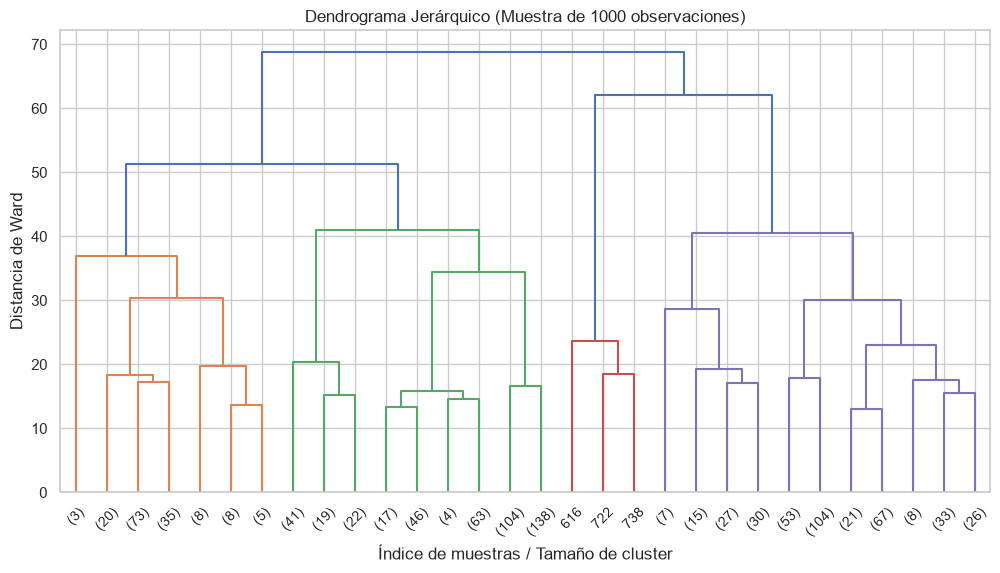

In [40]:
# linkage + dendrogram sobre una muestra de X
# Usamos una muestra de 1000 registros para que el dendrograma sea legible y eficiente
np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(X.shape[0], size=1000, replace=False)
X_sample = X[idx_sample]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Dendrograma Jerárquico (Muestra de 1000 observaciones)')
plt.xlabel('Índice de muestras / Tamaño de cluster')
plt.ylabel('Distancia de Ward')
plt.show()

### DBSCAN: ¿hay clusters de densidad aquí?

Probamos DBSCAN. Veréis que en alta dimensión tiende a juntar casi todo en **un solo cluster** y marcar el resto como **ruido**. Eso nos dice algo importante: estos datos son una nube continua, no grupos separados por densidad. Aquí DBSCAN funciona mejor como **detector de atípicos** que como segmentador.

In [41]:
# Ejecutar DBSCAN sobre la proyeccion PCA(2). Observar cuantos clusters y cuanto ruido.
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_pca)

n_clusters_ = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_ = list(labels_dbscan).count(-1)

print(f'Número estimado de clusters en PCA(2): {n_clusters_}')
print(f'Número estimado de puntos de ruido: {n_noise_} ({n_noise_/len(labels_dbscan)*100:.2f}%)')

Número estimado de clusters en PCA(2): 4
Número estimado de puntos de ruido: 239 (2.67%)


### Visualización de los segmentos (t-SNE)

Proyectamos con t-SNE (sobre una muestra) y coloreamos por el segmento de K-Means.

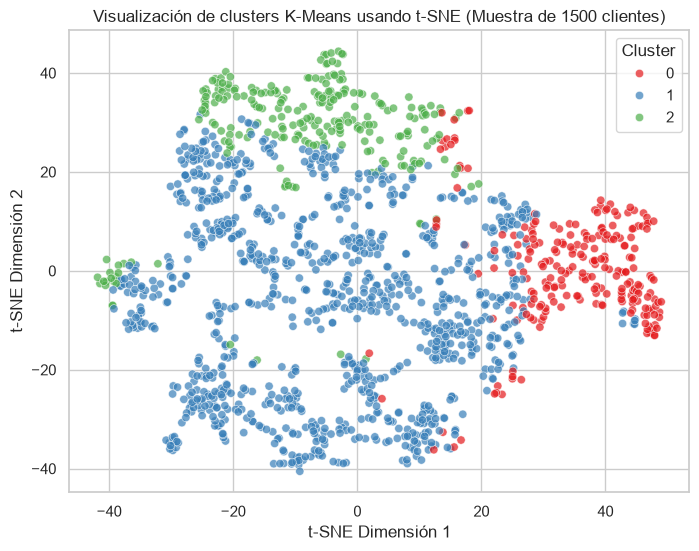

In [43]:
# t-SNE sobre una muestra de X, coloreado por el cluster de KMeans
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(df_clean.index, size=1500, replace=False)

X_sample_tsne = X[sample_indices]
labels_sample_kmeans = df_clean.loc[sample_indices, 'cluster_kmeans']

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne = tsne.fit_transform(X_sample_tsne)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_sample_kmeans, palette='Set1', alpha=0.7)
plt.title('Visualización de clusters K-Means usando t-SNE (Muestra de 1500 clientes)')
plt.xlabel('t-SNE Dimensión 1')
plt.ylabel('t-SNE Dimensión 2')
plt.legend(title='Cluster')
plt.show()

## Interpretación de los segmentos

Lo más importante en segmentación: **¿qué caracteriza a cada grupo?** Calculamos la media de cada variable por cluster y la estandarizamos entre clusters (rojo = por encima de la media, azul = por debajo). Así leemos el «perfil» de cada segmento.

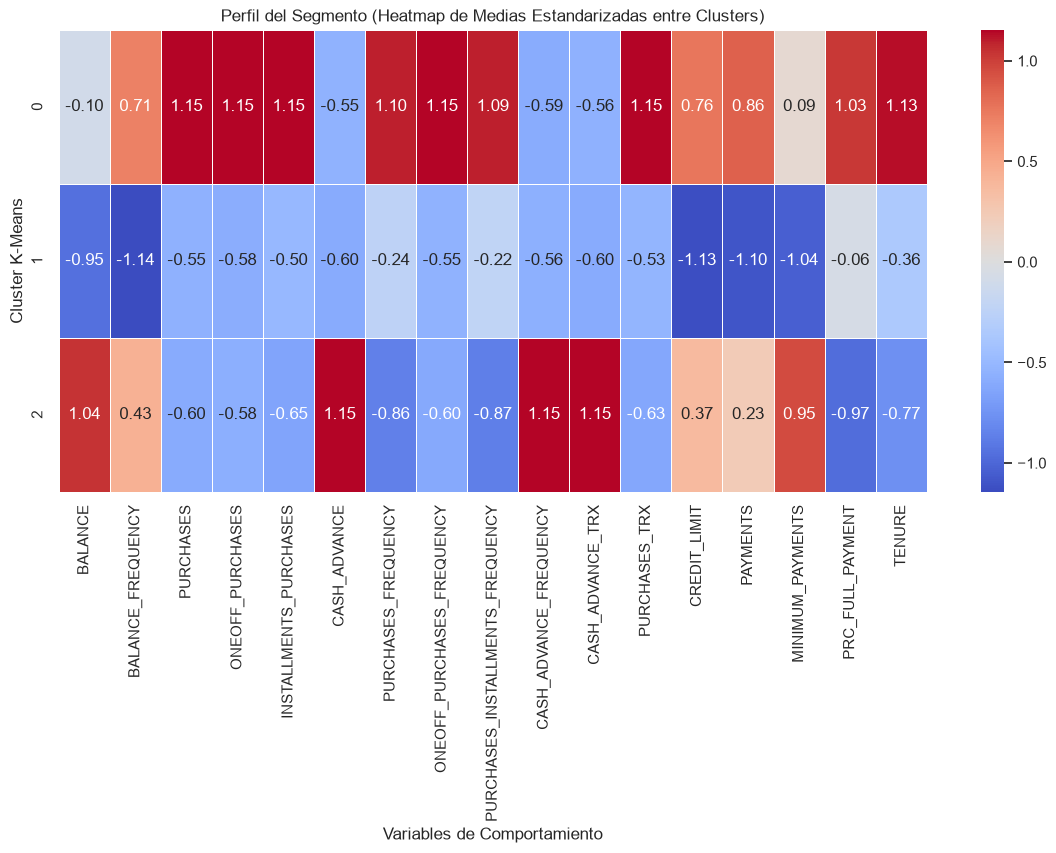

In [44]:
# 1. Anadir la columna 'cluster' al df original (sin escalar)
df_original_with_cluster = df_clean.copy()
# 2. Calcular la media de cada variable por cluster
cluster_means = df_original_with_cluster.groupby('cluster_kmeans').mean()
# 3. Estandarizar entre clusters y pintar un heatmap (perfil de cada segmento)
cluster_means_scaled = (cluster_means - cluster_means.mean()) / cluster_means.std()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_means_scaled, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.title('Perfil del Segmento (Heatmap de Medias Estandarizadas entre Clusters)')
plt.ylabel('Cluster K-Means')
plt.xlabel('Variables de Comportamiento')
plt.show()

Leyendo el heatmap se pueden nombrar los segmentos en términos de **negocio**, por ejemplo: clientes de alto saldo y muchas compras (VIP), clientes que tiran de adelantos de efectivo (riesgo), clientes poco activos, etc. Ese nombre y la estrategia asociada es justo el entregable que pide el caso.

## Detección de anomalías (Isolation Forest)

Identificamos los clientes con comportamiento más atípico (posible fraude, errores de datos o clientes premium fuera de norma).

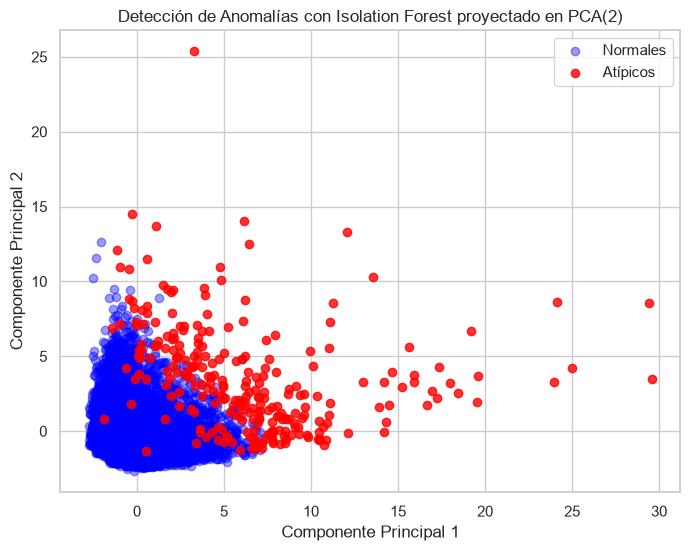

Se han detectado 269 clientes atípicos.


In [46]:
# IsolationForest sobre X, marcar los atipicos (-1) y pintarlos sobre PCA(2)
iso_forest = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
anomalias = iso_forest.fit_predict(X)

plt.figure(figsize=(8, 6))
# Pintar puntos normales
plt.scatter(X_pca[anomalias == 1, 0], X_pca[anomalias == 1, 1], c='blue', alpha=0.4, label='Normales')
# Pintar atípicos
plt.scatter(X_pca[anomalias == -1, 0], X_pca[anomalias == -1, 1], c='red', alpha=0.8, label='Atípicos')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Detección de Anomalías con Isolation Forest proyectado en PCA(2)')
plt.legend()
plt.show()

print(f"Se han detectado {np.sum(anomalias == -1)} clientes atípicos.")

---
## Para ir más allá (opcional)

- **Ingeniería de KPIs**: derivar variables como *ratio de uso del límite* (`BALANCE / CREDIT_LIMIT`) o *compra media por transacción* suele mejorar mucho los segmentos.
- **UMAP / HDBSCAN** para visualización y clustering por densidad más robusto.
- **Transformación logarítmica** de las variables sesgadas antes de escalar.

## Conclusiones

- Sin etiqueta, la segmentación se valida con métricas internas (*silhouette*, etc.) y, sobre todo, con la **interpretabilidad** de los perfiles.
- Imputar y **escalar** fue imprescindible aquí (a diferencia de las setas).
- K-Means, GMM y Aglomerativo dan segmentos coherentes; DBSCAN reveló que los datos son una nube continua (mejor como detector de atípicos).
- El heatmap de perfiles convierte los clusters en **segmentos de negocio accionables**.